# Práctica: Análisis de Datos y Clustering (Auto MPG)

 * **Autor:** Jolehisy Acevedo Medina
 * **Fecha:** 29/03/2026
 * **Asigantura:** Informática Industrial Avanzada
 * **Máster en Ingeniería Industrial**
 * **Universidad de La Laguna**

## Descripción del Dataset
Para esta tarea vamos a utilizar el dataset **"California Housing"**, que contiene datos del censo sobre los distritos de California. Es un dataset que combina variables continuas y categóricas.

Entre las variables destacan:
* **housing_median_age**: Edad media de las casas del distrito.
* **total_rooms** / **total_bedrooms**: Total de habitaciones y dormitorios.
* **median_income**: Ingreso medio de los residentes.
* **ocean_proximity**: Ubicación respecto al mar (Variable categórica de texto).

## Objetivos del Proyecto
El objetivo de este cuaderno es aplicar técnicas de Inteligencia Artificial y Análisis de Datos industrial siguiendo estos pasos:
1. **Análisis Exploratorio (EDA)**: Cargar los datos y revisar su estructura inicial.
2. **Limpieza y Preparación**: Localizar valores nulos (datos faltantes), tratarlos adecuadamente y convertir las variables de texto a formato numérico para que la IA pueda procesarlas.
3. **Clustering (Aprendizaje No Supervisado)**: Aplicar algoritmos como *K-Means* y *Gaussian Mixture Models (GMM)* para que la IA agrupe automáticamente los vehículos según sus similitudes técnicas.
4. **Evaluación y Comparación**: Reducir las dimensiones para visualizar los clústeres generados y comparar el rendimiento de ambos algoritmos.

### 1. Importación de Librerías y Carga de Datos
El primer paso en cualquier proyecto de análisis de datos es importar las herramientas necesarias. Utilizaremos **Pandas**, que es la librería estándar en Python para el manejo de estructuras de datos tabulares (DataFrames). 

A continuación, cargamos el dataset `housing` directamente desde un repositorio público.

In [9]:
# 1. Importamos la librería pandas. 
import pandas as pd

# 2. Le decimos dónde está el archivo. En este caso, el archivo está en internet, así que le damos la dirección URL.
url = 'https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv'

# 3. Leemos el archivo CSV y lo guardamos en una variable llamada 'df' (Data Frame).
df = pd.read_csv(url)

# 4. Imprimimos un mensaje para confirmar que los datos se han cargado correctamente.
print("Datos cargados")

Datos cargados


### 2. Visualización Inicial de los Datos
Para comprobar que el dataframe se ha construido correctamente, extraemos las primeras y las últimas. Esto nos permite familiarizarnos con la magnitud de los datos.

In [10]:
# Mostramos las 5 primeras filas para ver el encabezado
print("--- PRIMERAS 5 FILAS ---")
display(df.head())

# Mostramos las 5 últimas filas para comprobar el final del archivo
print("\n--- ÚLTIMAS 5 FILAS ---")
display(df.tail())

--- PRIMERAS 5 FILAS ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



--- ÚLTIMAS 5 FILAS ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


 **Observaciones de la Visualización Inicial:**
Efectivamente, comprobamos que todas las columnas son numéricas (coordenadas, ingresos, edades) excepto la columna `ocean_proximity`, que contiene texto (ej. "NEAR BAY", "INLAND"). Esta columna requerirá codificación más adelante.

### 3. Tipos de Datos y Detección de Valores Nulos
Los algoritmos de Inteligencia Artificial requieren datos limpios y, por lo general, en formato numérico. Con el método `.info()` revisaremos qué tipo de dato contiene cada columna (números o texto). 

Además, es vital identificar si existen valores nulos (datos faltantes causados por errores de medición o de registro), ya que estos generarán errores en los algoritmos de Clustering que aplicaremos más adelante.

In [11]:
# Revisamos la estructura interna de la tabla y los tipos de variables
print("--- TIPOS DE DATOS POR COLUMNA ---")
df.info()

# Contamos cuántos huecos en blanco (nulos) hay en cada columna
print("\n--- RECUENTO DE VALORES NULOS ---")
display(df.isnull().sum())

--- TIPOS DE DATOS POR COLUMNA ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB

--- RECUENTO DE VALORES NULOS ---


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Se puede observar que el recuento de nulos revela que **faltan 207 datos en la columna `total_bedrooms`**.

### 4. Estadísticas Descriptivas
Finalmente, realizamos un resumen estadístico de las variables numéricas. Esto nos proporciona una visión rápida de los valores medios, las desviaciones estándar (dispersión de los datos) y los valores máximos y mínimos.

In [12]:
# Generamos el resumen estadístico
print("--- ESTADÍSTICA DESCRIPTIVA ---")
display(df.describe())

--- ESTADÍSTICA DESCRIPTIVA ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


> **Conclusiones de la Estadística Descriptiva:**
Observamos diferencias de escala muy grandes entre las variables. Por ejemplo, `median_income` se mueve en valores de un solo dígito (media de 3.8), mientras que `total_rooms` llega a valores en los miles (media de 2635).

## 5. Limpieza y Preparación de Datos (Tratamiento de Nulos)
Para poder alimentar a los algoritmos de Clustering, vamos a realizar dos operaciones críticas de preprocesamiento:

1. **Tratamiento de Nulos:** Imputaremos los 207 valores faltantes de `total_bedrooms` utilizando la mediana de dicha columna, ya que la mediana es más robusta frente a valores atípicos (casas gigantes con muchas habitaciones frente a casas pequeñas con pocas) que la media aritmética.
2. **Codificación de Variables Categóricas:** La variable `ocean_proximity` contiene texto sin un orden jerárquico. Para evitar que la IA asuma que una ubicación "vale más" que otra, utilizaremos la técnica de *One-Hot Encoding* mediante la función `pd.get_dummies()` de Pandas, convirtiendo el texto en variables binarias (0 y 1).

In [13]:
# 1. TRATAMIENTO DE NULOS
mediana_habitaciones = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(mediana_habitaciones)

# VISUALIZACIÓN ANTES DE CODIFICAR
print("--- 1. COLUMNA ORIGINAL (SIN SUSTITUIR) ---")
display(df[['ocean_proximity']].head())

print("\n--- 2. RECUENTO DE CASAS POR CLASE (TEXTO) ---")
# El método value_counts() nos dice cuántas casas pertenecen a cada categoría
display(df['ocean_proximity'].value_counts())


# 2. CODIFICACIÓN DE TEXTO A NÚMEROS (One-Hot Encoding con Pandas)
# Generamos las nuevas columnas de ceros y unos
df = pd.get_dummies(df, columns=['ocean_proximity'], dtype=int)


# --- VISUALIZACIÓN DESPUÉS DE CODIFICAR ---
print("\n--- 3. DATOS SUSTITUIDOS ---")
display(df.head())

print("\n--- 4. RECUENTO FINAL DE NULOS ---")
display(df.isnull().sum())

--- 1. COLUMNA ORIGINAL (SIN SUSTITUIR) ---


,ocean_proximity
0,NEAR BAY
1,NEAR BAY
2,NEAR BAY
3,NEAR BAY
4,NEAR BAY



--- 2. RECUENTO DE CASAS POR CLASE (TEXTO) ---


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


--- 3. DATOS SUSTITUIDOS ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0



--- 4. RECUENTO FINAL DE NULOS ---


longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity_<1H OCEAN     0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64

> **Conclusiones de la Limpieza y Codificación (Antes y Después):**
> * **Transformación:** La técnica de *One-Hot Encoding* (`pd.get_dummies`) ha funcionado. El texto ha desaparecido y, en su lugar, el dataset ha incorporado 5 nuevas columnas binarias al final. Ahora, si una casa está en una isla, tendrá un `1` en la columna `ocean_proximity_ISLAND` y un `0` en el resto.
> * **Dataset:** La comprobación final de nulos arroja un total de 0. Hemos convertido el dataset en una matriz 100% numérica, continua y sin huecos, cumpliendo el requisito estricto para poder aplicar la Inteligencia Artificial (K-Means y GMM) en el siguiente paso.

## 6. Selección del Número Óptimo de Clústeres
Antes de aplicar los algoritmos definitivos, necesitamos determinar matemáticamente cuántos grupos (K) existen naturalmente en nuestros datos. 

Como el dataset contiene múltiples dimensiones y no podemos usar un dendrograma (propio del Clustering Jerárquico), utilizaremos el **Método del Codo (Elbow Method)** para evaluar la inercia del modelo K-Means con diferentes valores de K.

*Para que el cálculo de distancias sea correcto, es obligatorio estandarizar (escalar) los datos previamente.*

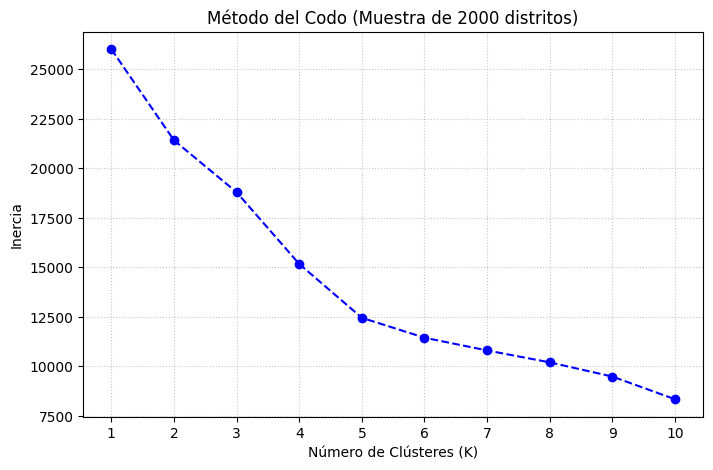

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Tomamos una muestra aleatoria de 2000 filas (porque el dataset es grande y queremos que el método del codo sea más rápido)
df_muestra = df.sample(n=2000, random_state=42)

# 2. ESCALADO DE DATOS
scaler = StandardScaler()
df_escalado_muestra = scaler.fit_transform(df_muestra)

# 3. MÉTODO DEL CODO
inercias = []
rango_k = range(1, 11)

for k in rango_k:
    modelo_temp = KMeans(n_clusters=k, random_state=42, n_init='auto')
    modelo_temp.fit(df_escalado_muestra)
    inercias.append(modelo_temp.inertia_)

# 4. DIBUJAMOS EL GRÁFICO DEL CODO
plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercias, marker='o', linestyle='--', color='b')
plt.title('Método del Codo (Muestra de 2000 distritos)')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia')
plt.xticks(rango_k)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

> ### Selección del número de Clústeres (K)
> La elección del número de clústeres no se basa en minimizar la inercia absoluta (que tendería a cero si K fuera igual al número de muestras), sino en optimizar la **varianza explicada por cada nuevo clúster**. 
>
> 1. **Análisis de la Pendiente:** Observamos que entre K=1 y K=3 la "ganancia de información" es máxima. A partir de K=4, entramos en una zona de rendimientos decrecientes donde la complejidad del modelo aumenta sin una mejora proporcional en la estructura de los datos.
> 2. **Validación:** El uso de K=3 asegura que los clústeres no solo sean compactos internamente, sino que estén lo suficientemente alejados entre sí para ser considerados perfiles de vivienda distintos y útiles para la toma de decisiones.

## 7. Modelado y Entrenamiento (K-Means vs GMM)
En esta fase, vamos a entrenar los dos algoritmos con el dataset completo (escalado) solicitando la creación de 3 clústeres (K=3), tal como nos indicó el método del codo.
1. **K-Means**: Modelo de fronteras rígidas (*hard-clustering*).
2. **GMM**: Modelo probabilístico (*soft-clustering*).

In [ ]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Escalado completo de los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 2. Entrenamos K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters_kmeans = kmeans.fit_predict(X_scaled)

# 3. Entrenamos GMM
gmm = GaussianMixture(n_components=3, random_state=42)
clusters_gmm = gmm.fit_predict(X_scaled)

print("Modelos entrenados")

Modelos entrenados


## 8. Análisis Visual en el Espacio Original
Lo habitual al llegar a este punto es aplicar directamente una reducción de dimensionalidad (como PCA) para ver los datos, ya que los seres humanos no podemos visualizar un gráfico en 13 dimensiones. 

Sin embargo, dado que el PCA puede ser un concepto abstracto y generar distorsiones visuales, primero vamos a visualizar las dimensiones originales. Extraeremos una muestra de 500 casas y cruzaremos solo algunas variables clave (`median_income`, `housing_median_age`, etc.) para ver cómo han separado los datos *K-Means* y *GMM* en la vida real.

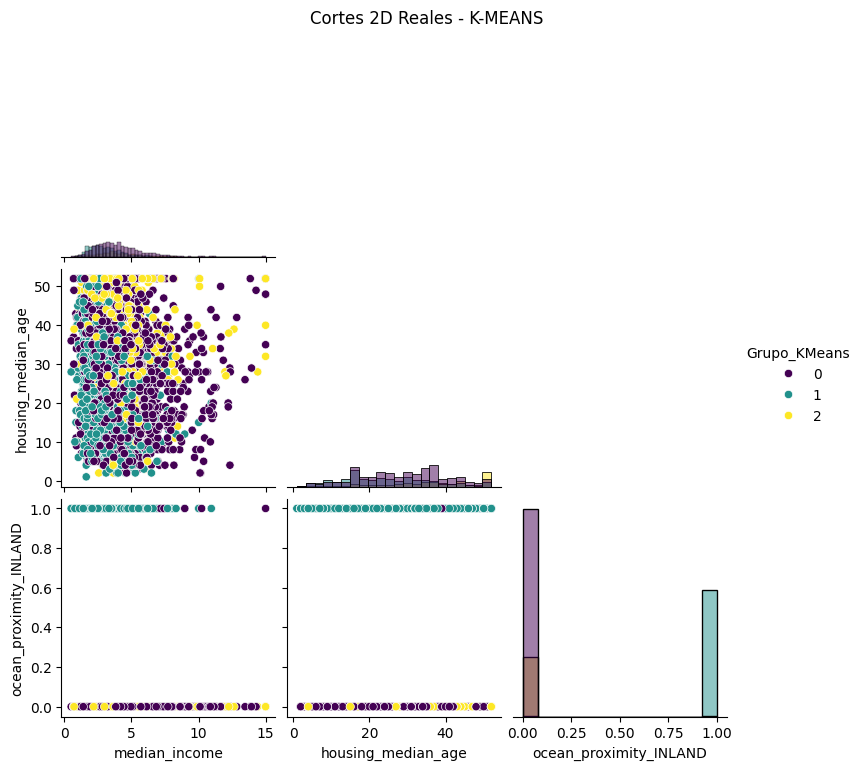

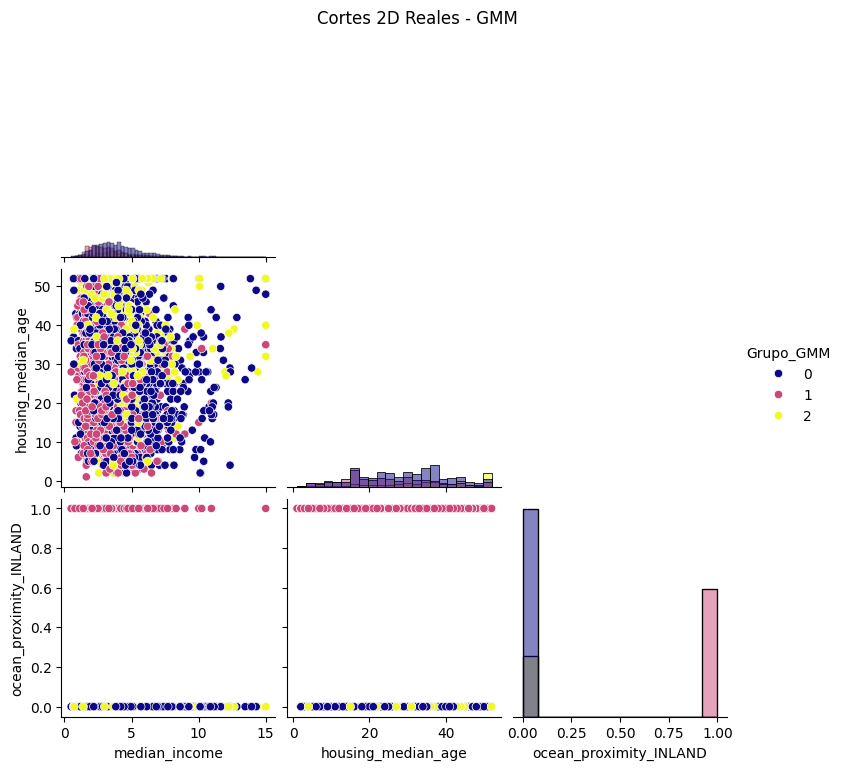

In [28]:
# 1. Tomamos una muestra de 4000 distritos usando sus índices
df_muestra = df.sample(n=4000, random_state=42).copy()
indices_muestra = df_muestra.index

# 2. Seleccionamos unas pocas variables representativas
columnas_clave = ['median_income', 'housing_median_age', 'ocean_proximity_INLAND']
df_visual = df_muestra[columnas_clave].copy()

# 3. Le asignamos a la muestra las etiquetas que predijo cada modelo
df_visual['Grupo_KMeans'] = clusters_kmeans[indices_muestra]
df_visual['Grupo_GMM'] = clusters_gmm[indices_muestra]

# 4. Dibujamos la vista de K-Means
sns.pairplot(df_visual.drop(columns=['Grupo_GMM']), hue='Grupo_KMeans', palette='viridis', corner=True, diag_kind='hist')
plt.suptitle("Cortes 2D Reales - K-MEANS", y=1.02)
plt.show()

# 5. Dibujamos la vista de GMM
sns.pairplot(df_visual.drop(columns=['Grupo_KMeans']), hue='Grupo_GMM', palette='plasma', corner=True, diag_kind='hist')
plt.suptitle("Cortes 2D Reales - GMM", y=1.02)
plt.show()

> **Interpretación de la Matriz**
> Al analizar las dimensiones originales, observamos que los algoritmos no utilizan todas las variables con el mismo peso para separar los clústeres:
> * **Variables determinantes (Fronteras limpias):** En el cruce de `median_income` con `ocean_proximity_INLAND` observamos que K-Means realiza cortes casi perfectos. El algoritmo ha identificado que la combinación de ubicación geográfica e ingresos es el principal motor que divide a los distritos californianos en 3 clases sociales.
> * **Variables secundarias (Solapamiento):** En variables como `housing_median_age`, observamos una alta mezcla de clústeres (los tres colores conviven en todas las edades). Lejos de ser un error, esto nos revela una conclusión de negocio: la antigüedad de la vivienda no es un factor discriminante fuerte para agrupar los distritos socioeconómicamente. Hay perfiles de alta renta (amarillo) tanto en casas nuevas como históricas.

> Como no podemos estar analizando gráficas cruzadas de 13 variables de forma manual, ahora sí, aplicaremos **PCA** para que las matemáticas nos hagan una "sombra" o resumen en 2D de toda esta información.

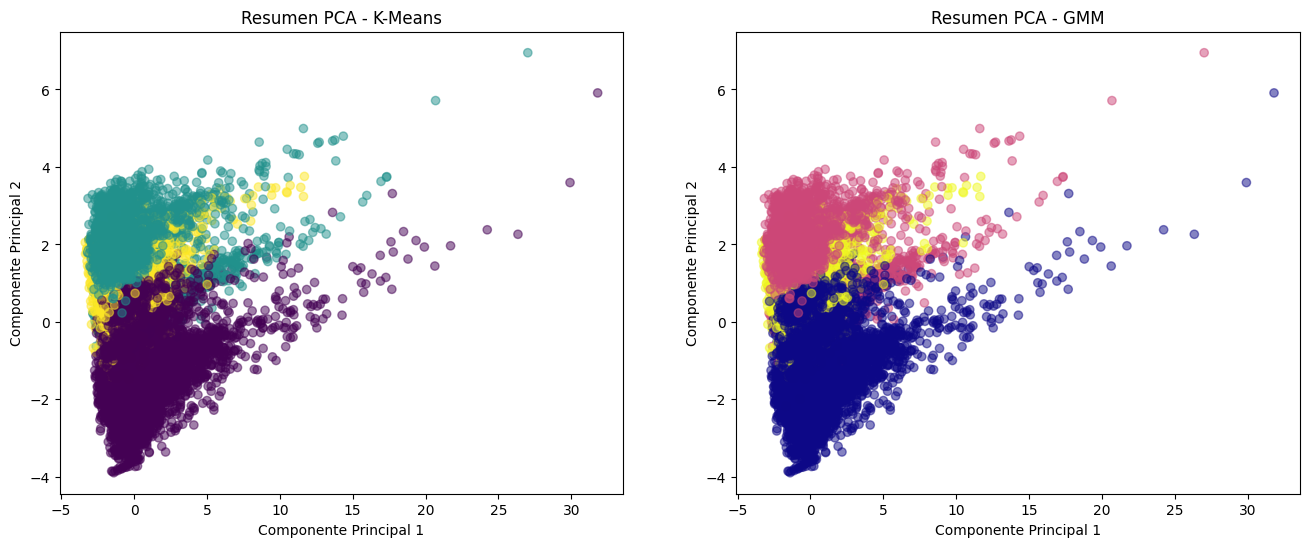

In [29]:
# 1. Aplicamos PCA para reducir las 13 columnas a solo 2 ejes principales
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. Dibujamos la comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_kmeans, cmap='viridis', alpha=0.5)
ax1.set_title('Resumen PCA - K-Means')
ax1.set_xlabel('Componente Principal 1')
ax1.set_ylabel('Componente Principal 2')

ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_gmm, cmap='plasma', alpha=0.5)
ax2.set_title('Resumen PCA - GMM')
ax2.set_xlabel('Componente Principal 1')
ax2.set_ylabel('Componente Principal 2')

plt.show()

## 9. Perfilado de los Clústeres
El aprendizaje no supervisado agrupa los datos matemáticamente asignándoles identificadores abstractos (0, 1, 2). Para que este análisis sea útil , interpretaremos los datos de estos grupos calculando las medias de sus características originales y asignándoles una etiqueta semántica.

In [34]:
import numpy as np

# 1. Añadimos la columna matemática (0, 1, 2) a nuestro dataframe original
df['Cluster_KMeans'] = clusters_kmeans

# 2. Calculamos la media de las variables más importantes para cada grupo
variables_perfil = ['median_income', 'housing_median_age', 'ocean_proximity_INLAND', 'ocean_proximity_<1H OCEAN']
perfiles = df.groupby('Cluster_KMeans')[variables_perfil].mean()

print("--- RADIOGRAFÍA DE LOS GRUPOS (MEDIAS) ---")
display(perfiles)

# 3. BAUTIZAMOS LOS GRUPOS (Interpretación Humana)
# Nota: Observando la tabla superior, asignamos un nombre lógico a cada número.
nombres_logicos = {
    0: "Costeras (<1H) / Clase Media-Alta", 
    1: "Zonas de Interior / Clase Trabajadora", 
    2: "Exclusivas (Océano/Bahía) / Históricas"
}

# 4. Creamos una nueva columna con el nombre en texto
df['Perfil_Socioeconomico'] = df['Cluster_KMeans'].map(nombres_logicos)

print("\n--- MUESTRA FINAL ---")
display(df[['median_income', 'housing_median_age', 'ocean_proximity_INLAND', 'ocean_proximity_<1H OCEAN', 'Perfil_Socioeconomico']].sample(10, random_state=42))

--- RADIOGRAFÍA DE LOS GRUPOS (MEDIAS) ---


,median_income,housing_median_age,ocean_proximity_INLAND,ocean_proximity_<1H OCEAN
Cluster_KMeans,,,,
0,4.192634,28.947911,0.005565,0.822934
1,3.161645,24.160539,0.993873,0.005821
2,4.219611,36.848254,0.000635,0.024444



--- MUESTRA FINAL ---


,median_income,housing_median_age,ocean_proximity_INLAND,ocean_proximity_<1H OCEAN,Perfil_Socioeconomico
20046,1.6812,25.0,1,0,Zonas de Interior / Clase Trabajadora
3024,2.5313,30.0,1,0,Zonas de Interior / Clase Trabajadora
15663,3.4801,52.0,0,0,Exclusivas (Océano/Bahía) / Históricas
20484,5.7376,17.0,0,1,Costeras (<1H) / Clase Media-Alta
9814,3.7250,34.0,0,0,Exclusivas (Océano/Bahía) / Históricas
13311,4.7147,12.0,1,0,Zonas de Interior / Clase Trabajadora
7113,5.0839,36.0,0,1,Costeras (<1H) / Clase Media-Alta
7668,3.6908,38.0,0,1,Costeras (<1H) / Clase Media-Alta
18246,4.8036,4.0,0,0,Exclusivas (Océano/Bahía) / Históricas
5723,8.1132,45.0,0,1,Costeras (<1H) / Clase Media-Alta


> **Conclusión del Perfilado**
> 
> La tabla de medias nos permite "ponerle cara" a las matemáticas. Observando las variables, hemos descubierto tres realidades distintas en el mercado de California:
> 1. **Zonas de Interior / Clase Trabajadora:** Distritos alejados de la costa (`INLAND` casi a 1) con los ingresos medios más bajos.
> 2. **Costeras (<1H) / Clase Media-Alta:** La gran mayoría de la población. Viven a menos de una hora del océano y tienen ingresos sostenidos.
> 3. **Exclusivas (Océano/Bahía) / Históricas:** Distritos con ingresos más altos, ubicaciones premium (muy pegados al agua) y con las propiedades más antiguas o clásicas del estado.

## 10. Comparación de Algoritmos (K-Means vs GMM)
Para cumplir con el objetivo de evaluar qué algoritmo se adapta mejor a la naturaleza de nuestro dataset, realizaremos dos pruebas:
1. **Evaluación Cuantitativa (Métricas):** Utilizaremos el **Silhouette Score** (Coeficiente de Silueta). Esta métrica va de -1 a 1 y evalúa qué tan cohesionado está un clúster internamente y qué tan separado está de los demás.
2. **Evaluación Cualitativa (Visualización):** Proyectaremos las 13 dimensiones a 2 ejes utilizando **PCA** para observar visualmente las fronteras de decisión creadas por cada modelo.


--- RESULTADOS DE LAS MÉTRICAS ---
K-Means - Silhouette Score: 0.2626
GMM     - Silhouette Score: 0.2631
----------------------------------


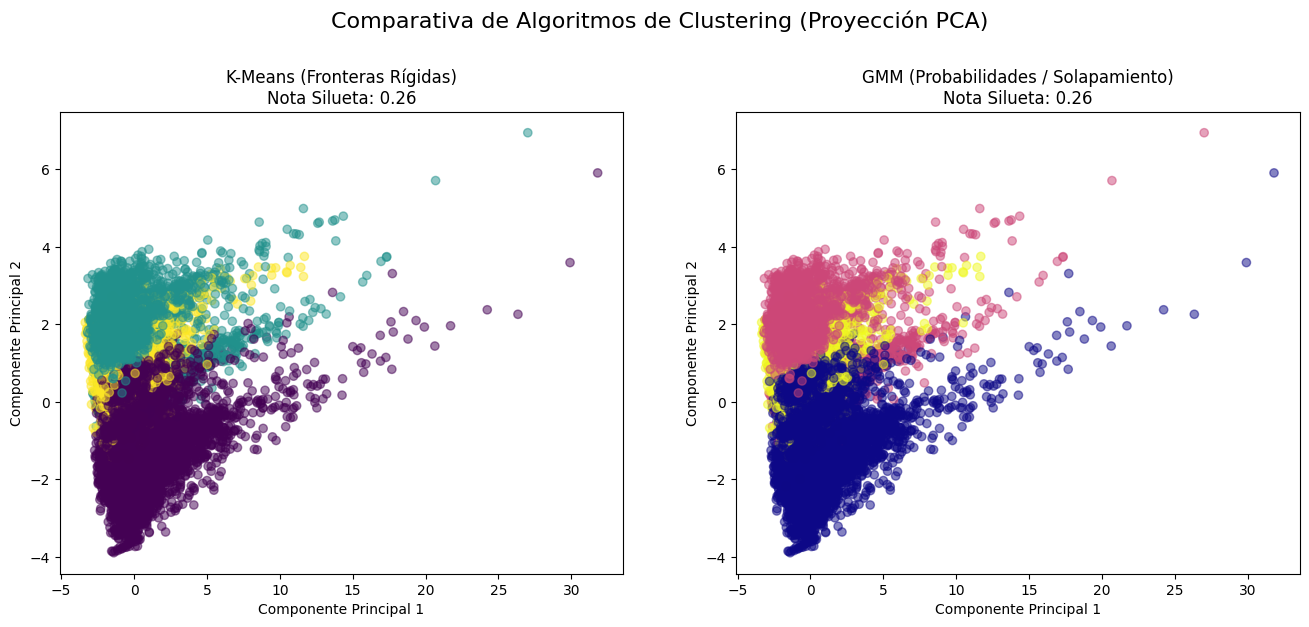

In [36]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. CÁLCULO DE MÉTRICAS (Silhouette Score)
# Usamos una muestra de 5000
sil_kmeans = silhouette_score(X_scaled, clusters_kmeans, sample_size=5000, random_state=42)
sil_gmm = silhouette_score(X_scaled, clusters_gmm, sample_size=5000, random_state=42)

print("\n--- RESULTADOS DE LAS MÉTRICAS ---")
print(f"K-Means - Silhouette Score: {sil_kmeans:.4f}")
print(f"GMM     - Silhouette Score: {sil_gmm:.4f}")
print("-" * 34)

# 2. REDUCCIÓN DE DIMENSIONALIDAD PARA VISUALIZAR
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. VISUALIZACIÓN DE LOS CLÚSTERES
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico para K-Means
ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_kmeans, cmap='viridis', alpha=0.5)
ax1.set_title(f'K-Means (Fronteras Rígidas)\nNota Silueta: {sil_kmeans:.2f}', fontsize=12)
ax1.set_xlabel('Componente Principal 1')
ax1.set_ylabel('Componente Principal 2')

# Gráfico para GMM
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_gmm, cmap='plasma', alpha=0.5)
ax2.set_title(f'GMM (Probabilidades / Solapamiento)\nNota Silueta: {sil_gmm:.2f}', fontsize=12)
ax2.set_xlabel('Componente Principal 1')
ax2.set_ylabel('Componente Principal 2')

plt.suptitle("Comparativa de Algoritmos de Clustering (Proyección PCA)", fontsize=16, y=1.05)
plt.show()

### Análisis de los Resultados
Al enfrentar ambos algoritmos y analizar sus métricas, llegamos a una conclusión muy reveladora:

1. **Empate Técnico en Métricas:** El *Silhouette Score* de **K-Means (0.2626)** y el de **GMM (0.2631)** son virtualmente idénticos. Lejos de haber un algoritmo ganador o perdedor, ambos logran exactamente el mismo nivel de cohesión y separación matemática.
2. **Convergencia Visual (PCA):** Los gráficos respaldan la métrica. Al observar la proyección en 2D, vemos que ambos algoritmos han identificado la misma estructura subyacente. Las fronteras de decisión y las asignaciones de clústeres son casi un calco el uno del otro.
3. **Veredicto y Robustez del Modelo:** El hecho de que dos enfoques matemáticos diametralmente opuestos (distancias euclidianas vs. densidades probabilísticas) converjan en la misma solución nos indica que **la segmentación en 3 perfiles es extremadamente robusta**. 

**Conclusión:** Podemos confiar plenamente en los 3 perfiles socioeconómicos hallados. Para su implementación elegiríamos **K-Means** porque es computacionalmente más ligero y más fácil que un modelo probabilístico complejo como GMM.